In [208]:
import numpy as np  
from sklearn import linear_model
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [137]:
model = linear_model.LinearRegression()

tes = pd.read_csv("Salary_Data[1].csv")

df = pd.DataFrame(tes)

removed = ["Gender", "Education Level", "Job Title"]

for o in removed:
    # Perform one-hot encoding
    dummies = pd.get_dummies(df[o], prefix=o, dtype=int)

    # Concatenate the new columns with the original DataFrame
    df = pd.concat([df, dummies], axis=1)

    # Optionally, remove the original categorical column
    df.drop(o, axis=1, inplace=True)

y = np.array([s for s in df["Salary"]])
df.drop("Salary", axis=1, inplace=True)

cols = [col for col in df.columns]
rows = df.shape[0]

df


,Age,Years of Experience,Gender_Female,Gender_Male,Gender_Other,Education Level_Bachelor's,Education Level_Bachelor's Degree,Education Level_High School,Education Level_Master's,Education Level_Master's Degree,...,Job Title_Supply Chain Manager,Job Title_Technical Recruiter,Job Title_Technical Support Specialist,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer
0,32.0,5.0,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,28.0,3.0,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,45.0,15.0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,36.0,7.0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,52.0,20.0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6699,49.0,20.0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6700,32.0,3.0,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
6701,30.0,4.0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6702,46.0,14.0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [181]:
fixed_data = np.empty((len(cols), rows))


for i in range(rows):
    arr = []
    for col in range(len(cols)):
        fixed_data[col][i] = df[cols[col]][i]
    

fixed_data
    




array([[32., 28., 45., ..., 30., 46., 26.],
       [ 5.,  3., 15., ...,  4., 14.,  1.],
       [ 0.,  1.,  0., ...,  1.,  0.,  1.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(205, 6704))

In [190]:
t = np.isnan(fixed_data)
d = np.where(t)
b = d

tes2 = np.isnan(y)
tes2 = np.where(tes2)
tes2




(array([], dtype=int64),)

In [183]:
for i in range(len(b[0])):
    med = df[cols[i]].median()
    fixed_data[b[0][i]][b[1][i]] = med

In [189]:
med = pd.DataFrame(y).median()

for i in tes2:
    y[i] = med

In [198]:
model.fit(fixed_data.T, y)
print(f"Coefficient (slope): {model.coef_[0]}")
print(f"Intercept: {model.intercept_}")

Coefficient (slope): 1038.464013661335
Intercept: 92723.99977214655


In [ ]:
y_pred = model.predict(fixed_data.T)

array([ 90000.,  65000., 150000., ...,  55000., 140000.,  35000.],
      shape=(6704,))

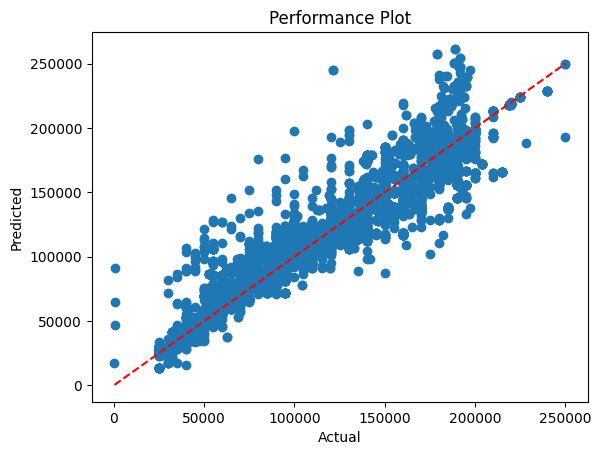

In [213]:
plt.scatter(y, y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Performance Plot')
plt.show()

In [218]:
loss = sum([(y[i] - y_pred[i])**2 for i in range(len(y))])/len(y)
loss


np.float64(310746465.34380245)

In [239]:
fixed_data = np.array(fixed_data)


params = np.dot(np.dot(np.linalg.inv(np.dot(fixed_data, fixed_data.T)), fixed_data), y)

params.shape


(205,)

In [ ]:
def f(x):
    res = []

(6704,)

array([[32., 28., 45., ..., 30., 46., 26.],
       [ 5.,  3., 15., ...,  4., 14.,  1.],
       [ 0.,  1.,  0., ...,  1.,  0.,  1.],
       ...,
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]], shape=(205, 6704))

In [ ]:
import numpy as np

def gradient_descent(X, y, weights, learning_rate, n_epochs, batch_size=1, method='batch'):
    """
    Perform gradient descent optimization.
    
    Args:
        X: Feature matrix of shape (m, n)
        y: Target values of shape (m,)
        weights: Initial weights of shape (n,)
        learning_rate: Step size for gradient descent
        n_epochs: Number of complete passes through the dataset
        batch_size: Size of batches for mini-batch gradient descent (default: 1)
        method: Type of gradient descent ('batch', 'stochastic', or 'mini_batch')
    
    Returns:
        Optimized weights
    """
    # Your code here

    row, col = X.shape

    if method == 'stochastic':
        for i in range(n_epochs):
            for j in range(row):
                y_pred = X[j, :] @ weights
                L = (y_pred - y[j])**2
                dL = 2 * (y_pred - y[j]) * X[j, :]
                weights = weights - (learning_rate * dL)

    elif method == 'mini_batch':
        b = row // batch_size
        for i in range(n_epochs):
            start, end = 0, b
            for j in range(b):
                y_pred = X[start:end, :] @ weights
                L = (np.mean(np.square(y_pred - y[start:end])))
                dL = (2/b) * X[start:end, :].T @ (y_pred - y[start:end]) 
                weights = weights - (learning_rate * dL)
                start = end
                end = end + b

    else:
        for i in range(n_epochs):
            y_pred = X @ weights
            L = (np.mean(np.square(y_pred - y)))
            dL = (2/row) * X.T @ (y_pred - y) 
            weights = weights - (learning_rate * dL)

    return weights
            

